# Main usage

This notebook walks through a complete **customics** workflow on the bundled toy dataset:

1. Load and explore multi-omics data
2. Split into train / validation / test sets
3. Configure the model architecture
4. Build and train a `CustOMICS` model
5. Evaluate classification and survival performance
6. Visualise the learned latent space
7. Stratify patients by predicted risk (Kaplan-Meier)
8. Explain model decisions with SHAP values
9. Save and reload a trained model

---

## Architecture at a glance

```
  protein  ──► AE_protein  ──┐
                             │
  rna      ──► AE_rna    ──►─┤  Central VAE  ──► Classifier (tumour subtype)
                             │   (latent z)
  methyl   ──► AE_methyl   ──┘               └──► Survival predictor (Cox)
```

**Phase 1** (epochs 0 → `switch`): each source autoencoder is trained
independently; task heads operate on per-source representations.
**Phase 2** (epochs `switch` → end): the central VAE integrates all sources
into a unified latent space used by the task heads.


In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import customics
from customics import CustOMICS

---

## 1. Loading and Exploring the Data

The toy dataset contains **100 patients** with three omics modalities:

| Source    | Features | Description                        |
| --------- | -------- | ---------------------------------- |
| `protein` | 160      | Reverse Phase Protein Array (RPPA) |
| `rna`     | 131      | RNA-seq gene expression            |
| `methyl`  | 367      | DNA methylation (450K array)       |


In [2]:
mdata = customics.toy_dataset()

/Users/alihamraoui/projects/tests/CustOmics/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


`mdata` is a [`mudata.MuData`](https://mudata.readthedocs.io/stable/) object:

- `mdata.mod` — dict of modality names → `AnnData` matrices (rows = samples, columns = features)
- `mdata.obs` — shared clinical metadata DataFrame indexed by **sample ID**


In [3]:
list(mdata.mod.keys())

['rna', 'protein', 'methyl']

In [4]:
mdata["protein"].to_df().head()

probe,ACC1,ACC_pS79,ACVRL1,Akt_pS473,PRAS40_pT246,Annexin.1,AR,A.Raf_pS299,ASNS,ATM,...,XBP1,XRCC1,Ku80,YAP,YAP_pS127,YB.1,YB.1_pS102,14.3.3_beta,14.3.3_epsilon,14.3.3_zeta
subject1,-0.528421,-0.826949,2.465380,0.118108,2.682673,-0.473918,2.692947,0.392130,-1.458304,-0.518608,...,2.365702,-0.115504,2.125662,0.198529,0.263075,2.035369,3.276020,-0.164232,2.240264,0.390613
subject2,-0.804377,-0.858630,2.679618,1.163897,2.789568,0.326823,3.703054,-0.207030,-0.567368,-1.447359,...,2.369684,-0.250648,2.028639,0.294427,0.087710,2.748533,2.655492,-0.020322,2.584052,1.083867
subject3,0.596001,0.175652,2.782368,-1.550062,2.136330,-0.729363,3.987616,-0.065740,0.225819,0.321197,...,2.912468,0.235292,3.102378,0.717648,0.118142,2.608048,1.894032,0.423970,2.470960,0.355451
subject4,2.306769,2.387911,2.152993,0.175379,-0.243862,0.206090,3.851968,-0.347185,1.595250,2.998184,...,0.019668,2.319597,0.211079,0.178415,0.312633,-0.205992,0.151597,2.289823,0.153826,-0.634842
subject5,-0.948945,-0.640623,2.242055,0.829983,2.732090,-0.218177,2.376110,-0.510938,-1.030711,-0.125802,...,2.169958,-0.044484,2.905596,0.539468,0.338059,2.257715,2.718098,-0.190475,2.523407,0.445861


`mdata.obs` is a DataFrame whose index are sample IDs, and contains the following columns:

- an event-indicator (`OS`, 0 = censored, 1 = event)
- a survival-time column (`OS.time`, in days).
- **tumour subtype label** (`cluster.id`, classes 1–5)


In [5]:
mdata.obs.head()

,subjects,cluster.id,OS,OS.time
subject1,1,5,0,2531
subject2,2,5,1,759
subject3,3,5,1,2453
subject4,4,3,0,220
subject5,5,5,0,2431


We can show a quick summary of our omics and clinical data:


In [6]:
print("Omics sources loaded:")
for name in mdata.mod:
    print(f"  {name:10s}  {mdata[name].shape[0]:>4d} samples * {mdata[name].shape[1]:>4d} features")
print(f"\nClinical data  : {mdata.obs.shape[0]} rows * {mdata.obs.shape[1]} columns")

Omics sources loaded:
  rna          100 samples *  131 features
  protein      100 samples *  160 features
  methyl       100 samples *  367 features

Clinical data  : 100 rows * 4 columns



=== Label distribution (cluster.id) ===
cluster.id
1    35
2    13
3    19
4     8
5    25


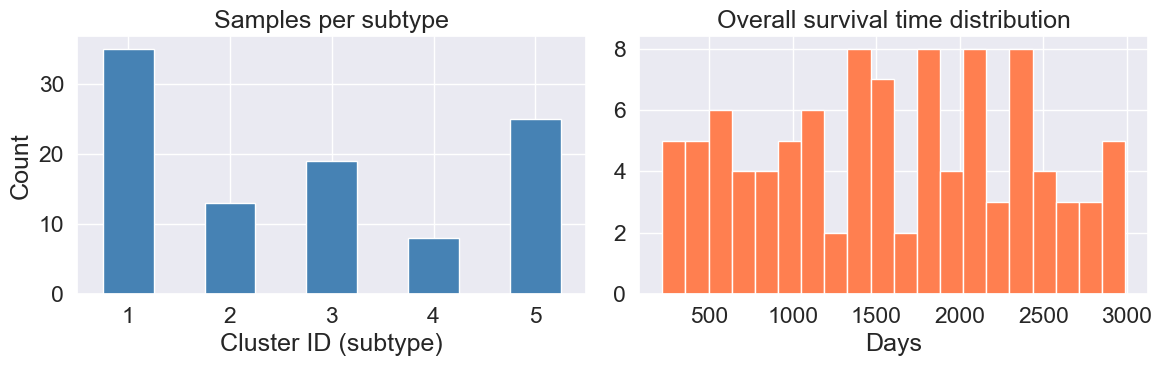

In [7]:
# Class distribution — the label we will train the classifier on.
print("\n=== Label distribution (cluster.id) ===")
counts = mdata.obs["cluster.id"].value_counts().sort_index()
print(counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Samples per subtype")
axes[0].set_xlabel("Cluster ID (subtype)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

mdata.obs["OS.time"].hist(bins=20, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Overall survival time distribution")
axes[1].set_xlabel("Days")
plt.tight_layout()
plt.show()

In [8]:
# get_shared_samples returns the intersection of sample IDs across all modalities.
# This ensures every downstream step uses exactly the same set of sample IDs.
shared_samples = customics.get_shared_samples(mdata)
print(f"Samples present in ALL sources and clinical data: {len(shared_samples)}")
print(f"First 5 sample IDs: {shared_samples[:5]}")

Samples present in ALL sources and clinical data: 100
First 5 sample IDs: ['subject1', 'subject10', 'subject100', 'subject11', 'subject12']


---

## 2. Splitting the Data

We split the full cohort into **train / validation / test** sets.
`get_sub_mudata` applies the same sample selection to all modalities simultaneously,
keeping the `MuData` object in sync.


In [9]:
samples_train, samples_test = train_test_split(shared_samples, test_size=0.20, random_state=42)
samples_train, samples_val = train_test_split(samples_train, test_size=0.15, random_state=42)

print(f"Train : {len(samples_train):>3d} samples")
print(f"Val   : {len(samples_val):>3d} samples")
print(f"Test  : {len(samples_test):>3d} samples")

Train :  68 samples
Val   :  12 samples
Test  :  20 samples


In [10]:
# prepare_input validates clinical columns and registers them in mdata.uns
# so fit() and evaluate() can find them without repeating column names each time.
label, event, surv_time = "cluster.id", "OS", "OS.time"
customics.prepare_input(mdata, label="cluster.id", event="OS", surv_time="OS.time")

# get_sub_mudata returns a new MuData filtered to the given sample IDs.
mdata_train = customics.get_sub_mudata(mdata, samples_train)
mdata_val = customics.get_sub_mudata(mdata, samples_val)
mdata_test = customics.get_sub_mudata(mdata, samples_test)

# Record input dimensions per source — used to configure the autoencoders below.
x_dim = {mod: mdata[mod].shape[1] for mod in mdata.mod}
print("Feature dimensions per source:", x_dim)

Feature dimensions per source: {'rna': 131, 'protein': 160, 'methyl': 367}


/Users/alihamraoui/projects/tests/CustOmics/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/alihamraoui/projects/tests/CustOmics/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/alihamraoui/projects/tests/CustOmics/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


---

## 3. Configuring the Model

`CustOMICS` is configured through five parameter dictionaries.
Each controls one component of the architecture.

### `source_params` — per-source autoencoders

One entry per omics modality. The autoencoder compresses raw features into a
compact `latent_dim`-dimensional representation.

| Key          | Type      | Description                                                        |
| ------------ | --------- | ------------------------------------------------------------------ |
| `input_dim`  | int       | Number of input features (from the data)                           |
| `hidden_dim` | list[int] | Hidden layer sizes (encoder direction; decoder mirrors in reverse) |
| `latent_dim` | int       | Per-source embedding dimension                                     |
| `norm`       | bool      | Use BatchNorm after each FC layer                                  |
| `dropout`    | float     | Dropout probability in [0, 1]                                      |

### `central_params` — central VAE

Receives the concatenation of all per-source embeddings and produces the
shared latent code **z** used by both task heads.

| Key          | Type      | Description                                        |
| ------------ | --------- | -------------------------------------------------- |
| `hidden_dim` | list[int] | Hidden layer sizes                                 |
| `latent_dim` | int       | Dimension of **z** (the integrated representation) |
| `beta`       | float     | Weight of the MMD regularisation term              |
| `norm`       | bool      | BatchNorm in layers                                |
| `dropout`    | float     | Dropout probability                                |

### `classif_params` — classifier head

Maps **z** → tumour subtype probabilities via a small MLP.

| Key             | Type      | Description                                  |
| --------------- | --------- | -------------------------------------------- |
| `n_class`       | int       | Number of output classes                     |
| `lambda`        | float     | Classification loss weight in the total loss |
| `hidden_layers` | list[int] | MLP hidden sizes                             |
| `dropout`       | float     | Dropout probability                          |

### `surv_params` — Cox survival head

Maps **z** → log-hazard score. Set `lambda = 0` to disable.

| Key          | Type      | Description                                           |
| ------------ | --------- | ----------------------------------------------------- |
| `lambda`     | float     | Cox loss weight (`0` = disabled)                      |
| `dims`       | list[int] | Hidden layer sizes (final output size is always 1)    |
| `activation` | str       | Activation name: `"SELU"`, `"ReLU"`, `"LeakyReLU"`, … |
| `l2_reg`     | float     | L2 regularisation on the survival head weights        |
| `norm`       | bool      | BatchNorm in layers                                   |
| `dropout`    | float     | Dropout probability                                   |

### `train_params` — optimiser & phase schedule

| Key      | Type  | Description                                 |
| -------- | ----- | ------------------------------------------- |
| `switch` | int   | Epoch where phase 1 ends and phase 2 begins |
| `lr`     | float | Adam learning rate                          |


In [11]:
# ── Training schedule ───────────────────────────────────────────────────
batch_size = 32
n_epochs = 30  # 30 epochs is enough for the 100-sample toy dataset

# ── Per-source autoencoder parameters ────────────────────────────────────
# x_dim is a dict {source_name: n_features}, computed from the data above.
# Using a dict comprehension keeps source_params in sync with x_dim automatically.
source_params = {
    source: {
        "input_dim": x_dim[source],  # auto-filled — do not hardcode
        "hidden_dim": [256, 128],
        "latent_dim": 64,
        "norm": True,
        "dropout": 0.2,
    }
    for source in x_dim
}

# ── Central VAE parameters ────────────────────────────────────────────
central_params = {
    "hidden_dim": [256, 128],
    "latent_dim": 64,  # dimension of the shared latent code z
    "norm": True,
    "dropout": 0.2,
    "beta": 1.0,  # MMD regularisation weight
}

# ── Classifier head parameters ──────────────────────────────────────
classif_params = {
    "n_class": 5,  # subtypes 1-5
    "lambda": 5.0,  # classification loss weight
    "hidden_layers": [64, 32],
    "dropout": 0.2,
}

# ── Survival head parameters ────────────────────────────────────────
# lambda=0 disables the Cox loss; the survival head is still built but not trained.
# To enable survival, set lambda > 0 and ensure OS / OS.time contain real data.
surv_params = {
    "lambda": 0.0,
    "dims": [32, 16],
    "activation": "SELU",
    "l2_reg": 1e-2,
    "norm": True,
    "dropout": 0.2,
}

# ── Optimiser & phase schedule ──────────────────────────────────────
# switch=15 means:
#   epochs 0–14  → Phase 1: source AEs train independently
#   epochs 15–29 → Phase 2: central VAE takes over, heads are jointly optimised
train_params = {"switch": 15, "lr": 1e-3}

print("source_params keys :", list(source_params.keys()))
print("input dimensions   :", {k: v["input_dim"] for k, v in source_params.items()})
print("central latent dim :", central_params["latent_dim"])
print(
    f"training phases    : phase 1 → epochs 0–{train_params['switch'] - 1}, "
    f"phase 2 → epochs {train_params['switch']}–{n_epochs - 1}"
)

source_params keys : ['rna', 'protein', 'methyl']
input dimensions   : {'rna': 131, 'protein': 160, 'methyl': 367}
central latent dim : 64
training phases    : phase 1 → epochs 0–14, phase 2 → epochs 15–29


---

## 4. Building and Training the Model

### Model instantiation

Pass the five config dicts to `CustOMICS`. The model is built immediately but
weights are random until `fit()` is called.


In [12]:
model = CustOMICS(
    source_params=source_params,
    central_params=central_params,
    classif_params=classif_params,
    surv_params=surv_params,
    train_params=train_params,
)
print(f"Total trainable parameters: {model.get_number_parameters():,}")

[INFO] (customics.model) Using cpu by default.


Total trainable parameters: 790,778


In [13]:
# fit() reads label/event/surv_time from mdata.uns (registered by prepare_input above).
# omics_val triggers validation loss logging after each epoch.
model.fit(
    mdata=mdata_train,
    omics_val=mdata_val,
    batch_size=batch_size,
    n_epochs=n_epochs,
    verbose=True,
);

[INFO] (customics.model) Epoch 1/30 | train=28.1554 | val=31.3453


[INFO] (customics.model) Epoch 2/30 | train=19.8262 | val=29.0017


[INFO] (customics.model) Epoch 3/30 | train=18.5581 | val=25.5669


[INFO] (customics.model) Epoch 4/30 | train=14.8026 | val=22.5208


[INFO] (customics.model) Epoch 5/30 | train=16.5802 | val=19.5704


...

[INFO] (customics.model) Epoch 26/30 | train=5.0474 | val=5.1783


[INFO] (customics.model) Epoch 27/30 | train=4.5562 | val=5.3988


[INFO] (customics.model) Epoch 28/30 | train=3.4257 | val=5.2837


[INFO] (customics.model) Epoch 29/30 | train=4.1434 | val=4.8389


[INFO] (customics.model) Epoch 30/30 | train=4.3941 | val=4.9779


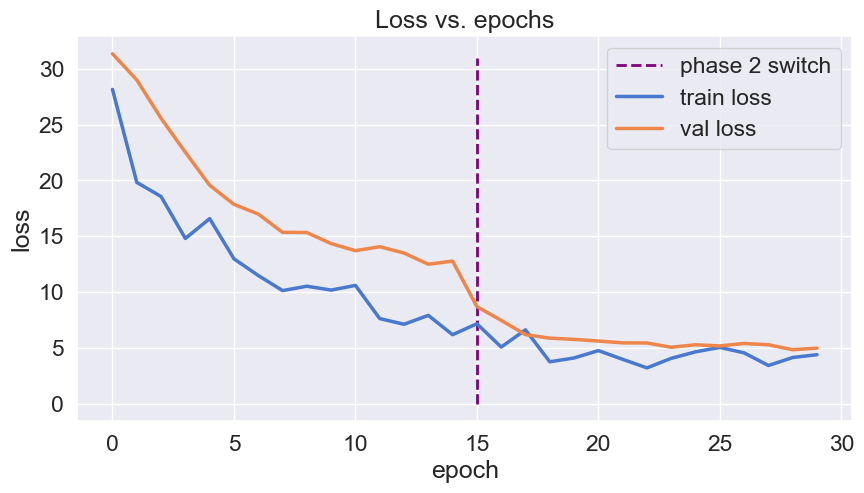

In [14]:
# Plot the train/validation loss curves to check for overfitting.
# The vertical dashed line marks the phase 1 → phase 2 transition.
model.plot_loss()

---

## 5. Evaluating the Model

`evaluate()` runs inference on the held-out **test set** and returns a metrics dict.

- **Classification** (`task="classification"`): accuracy, macro F1, weighted F1,
  and per-class ROC-AUC.
- **Survival** (`task="survival"`): concordance index (C-index) via the Cox head.

> Set `plot_roc=True` to overlay per-class ROC curves on a single figure.



── Classification metrics on the test set ──
  Accuracy                 : 1.0000
  F1-score                 : 1.0000
  Precision                : 1.0000
  Recall                   : 1.0000
  AUC                      : 1.0000


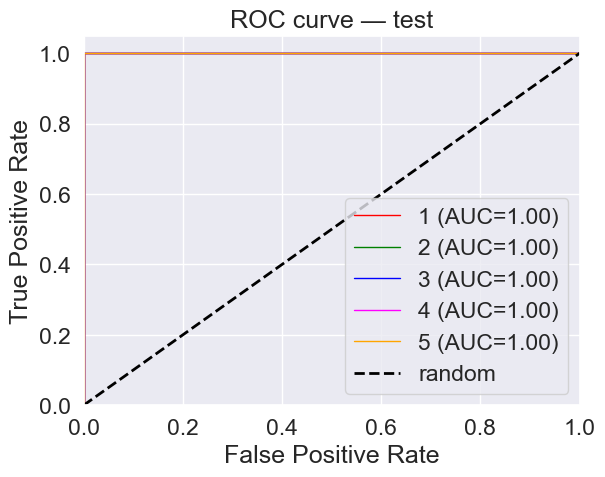

In [15]:
# Evaluate tumour-subtype classification on the test split.
# label/event/surv_time are read from mdata_test.uns (registered by prepare_input).
metrics = model.evaluate(
    mdata=mdata_test,
    task="classification",
    batch_size=1024,
    plot_roc=True,
)

print("\n── Classification metrics on the test set ──")
for k, v in metrics.items():
    print(f"  {k:<25s}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

In [16]:
# Evaluate the Cox survival head on the test split.
# With synthetic OS/OS.time the C-index will be ~0.5 (random), which is expected.
# Replace OS/OS.time with real data to obtain meaningful survival performance.
surv_metrics = model.evaluate(
    mdata=mdata_test,
    task="survival",
    batch_size=1024,
)

print("\n── Survival metrics on the test set ──")
print("C-index :", surv_metrics)


── Survival metrics on the test set ──
C-index : 0.3723404255319149


---

## 6. Visualising the Latent Space

`get_latent_representation()` encodes every sample in `mdata` through the
trained central VAE and returns a NumPy array of shape `(n_samples, latent_dim)`.

`plot_representation()` runs t-SNE on that array and colours each point by the
clinical label — a quick sanity check that the model has learned subtype-discriminative
features.


Latent space shape: (100, 64)  (n_samples × latent_dim)


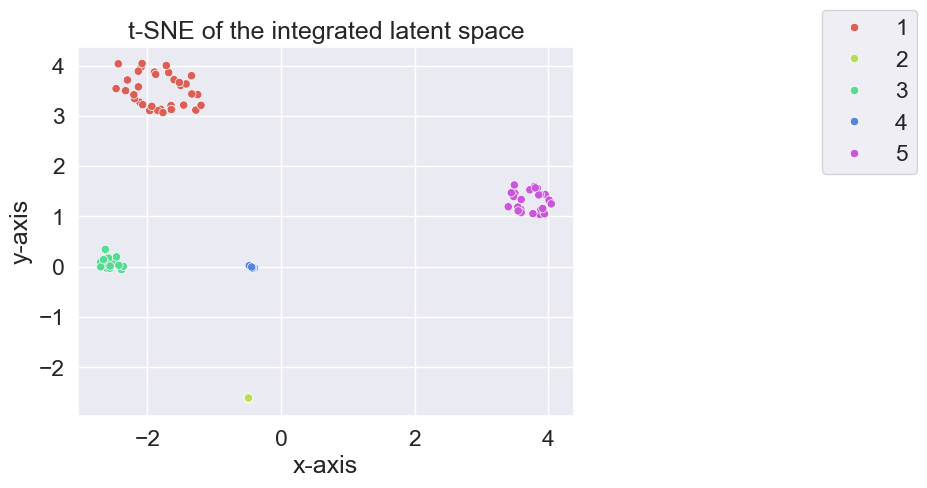

<Figure size 640x480 with 0 Axes>

In [17]:
from pathlib import Path

# Get the latent embedding for ALL samples (train + val + test combined).
z = model.get_latent_representation(mdata)
print(f"Latent space shape: {z.shape}  (n_samples × latent_dim)")


# Create the results directory if it doesn't exist yet.
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

model.plot_representation(
    mdata=mdata,
    color=label,
    filename=RESULTS_DIR / "latent_representation",
    title="t-SNE of the integrated latent space",
    show=True,
)

---

## 7. Survival Risk Stratification

`stratify()` uses the Cox head to assign each sample a risk score, then splits
the cohort into high-risk / low-risk groups at the median score and draws a
Kaplan-Meier curve.

> **Note:** with synthetic survival data the curves will overlap.
> This section shows the API; meaningful separation requires real OS/OS.time.


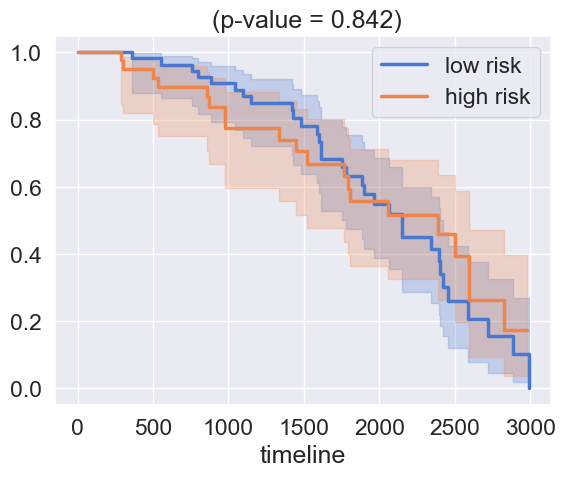

In [18]:
model.stratify(mdata=mdata, show=True)

---

## 8. Feature Importance with SHAP

`explain()` uses `shap.DeepExplainer` to compute feature-attribution values for
one omics source and one tumour subtype.

**Parameters:**

| Parameter   | Description                                                      |
| ----------- | ---------------------------------------------------------------- |
| `sample_id` | List of sample IDs to explain                                    |
| `mdata`     | Full `MuData` object                                             |
| `source`    | Which omics source to explain (`"rna"`, `"protein"`, `"methyl"`) |
| `subtype`   | Integer label of the class to explain (1-based here)             |
| `label`     | Column in `mdata.obs` containing the class labels                |
| `device`    | `"cpu"` or `"cuda"`                                              |
| `show`      | Display the SHAP summary plot inline                             |

The bar plot shows the **mean absolute SHAP value** for each feature — higher
means more influential for predicting the chosen subtype.


[INFO] (customics.model) Using cpu by default.


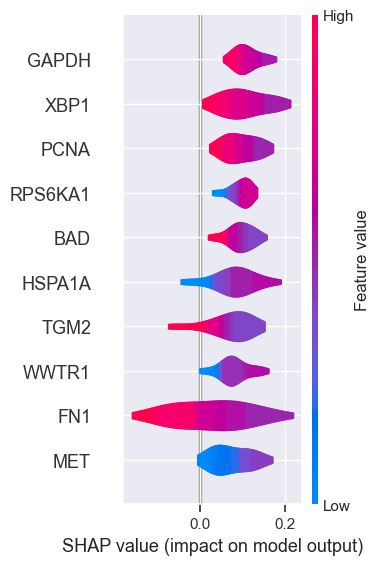

<Figure size 640x480 with 0 Axes>

In [19]:
# Feature importance for RNA expression → subtype 1
model.explain(sample_ids=shared_samples, mdata=mdata, source="rna", subtype=1, show=True)

[INFO] (customics.model) Using cpu by default.


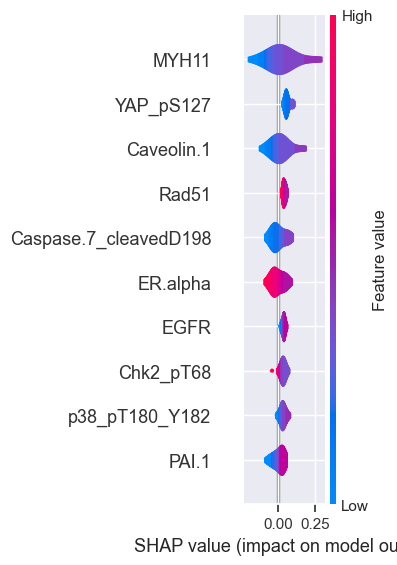

<Figure size 640x480 with 0 Axes>

In [20]:
# Feature importance for protein expression → subtype 1
model.explain(sample_ids=shared_samples, mdata=mdata, source="protein", subtype=1, show=True)

[INFO] (customics.model) Using cpu by default.


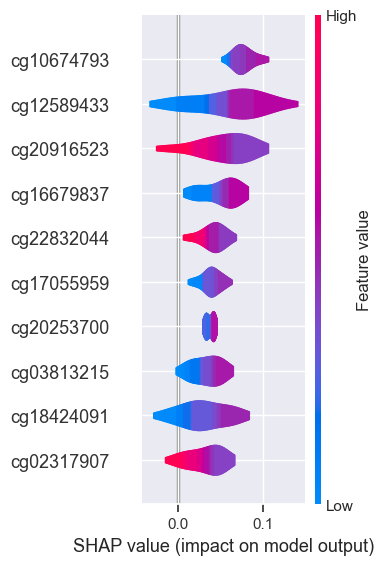

<Figure size 640x480 with 0 Axes>

In [21]:
# Feature importance for DNA methylation → subtype 1
model.explain(sample_ids=shared_samples, mdata=mdata, source="methyl", subtype=1, show=True)

---

## 9. Saving and Reloading the Model

`CustOMICS` uses PyTorch's standard `state_dict` / `load_state_dict` mechanism.
The helper methods `save()` and `load()` wrap this pattern so you don't need to
worry about the architecture parameters — `load()` reconstructs the full model
from the checkpoint.

> **Best practice:** save after the final training run so you can reproduce
> predictions without retraining.


In [22]:
checkpoint_path = RESULTS_DIR / "customics_model.pt"

# save() stores both the architecture config and the weight tensors.
model.save(checkpoint_path)

[INFO] (customics.model) Model saved to results/customics_model.pt


In [23]:
# load() is a class method — it rebuilds the model from the checkpoint file.
loaded_model = CustOMICS.load(checkpoint_path)
print(f"Parameters in loaded model: {loaded_model.get_number_parameters():,}")

[INFO] (customics.model) Using cpu by default.


[INFO] (customics.model) Model loaded from results/customics_model.pt


Parameters in loaded model: 790,778


In [24]:
# Sanity-check: predictions from the reloaded model should match the originals.
metrics_reloaded = loaded_model.evaluate(
    mdata=mdata_test,
    task="classification",
    batch_size=1024,
    plot_roc=False,
)
print("\n── Reloaded model — classification metrics ──")
for k, v in metrics_reloaded.items():
    print(f"  {k:<25s}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


── Reloaded model — classification metrics ──
  Accuracy                 : 1.0000
  F1-score                 : 1.0000
  Precision                : 1.0000
  Recall                   : 1.0000
  AUC                      : 1.0000
